# Sales Data Analysis Mini Project

In this project I am working with a real sales dataset that has a lot of messy and inconsistent data.
My goal is to clean the dataset using Pandas, create some new useful columns, and then analyze the sales
to find useful business insights.

## Step 1: Import Libraries
First I will import the libraries I need for this project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 2: Load the Dataset
Now I will load the sales dataset csv file.

In [2]:
df = pd.read_csv('sales_dataset.csv')

Let's look at the first 5 rows of the dataset.

In [3]:
df.head()

,Order ID,Order Date,Customer Name,Region,Product,Category,Quantity,Unit Price,Discount,Payment Method,Order Status,Sales Rep,Customer Segment,Shipping Date
0,ORD-1001,2024-04-24,USMAN AKHTAR,North,Gel Pens,Stationery,5,700,0.15,Cash,Cancelled,Hina,Student,2024-04-29
1,ORD-1002,2024-12-14,OMAR MALIK,North,Wireless Mouse,Accessories,8,2400,0.2,Card,Completed,Hina,Consumer,2024-12-18
2,ORD-1003,NaN,Danish Qureshi,North,Bluetooth Speaker,Electronics,3,9400,0.15,Cash,Completed,Nadia,Small Business,2024-10-27
3,ORD-1004,2025-02-14,Imran Anwar,South,Laptop Sleeve,Bags,5,3600,0,Cash,Completed,Hina,Student,2025-02-18
4,ORD-1005,2024-03-06,Laiba Butt,North,Laptop Sleeve,Bags,5,4000,0,Bank Transfer,Cancelled,Hina,Consumer,2024-03-14


## Step 3: Explore the Dataset
Before cleaning the data, I want to explore it first to understand what I am working with.

Shape of the dataset (rows and columns).

In [4]:
df.shape

(326, 14)

Column names in the dataset.

In [5]:
df.columns

Index(['Order ID', 'Order Date', 'Customer Name', 'Region', 'Product',
       'Category', 'Quantity', 'Unit Price', 'Discount', 'Payment Method',
       'Order Status', 'Sales Rep', 'Customer Segment', 'Shipping Date'],
      dtype='str')

Data types of each column.

In [6]:
df.dtypes

Order ID            str
Order Date          str
Customer Name       str
Region              str
Product             str
Category            str
Quantity            str
Unit Price          str
Discount            str
Payment Method      str
Order Status        str
Sales Rep           str
Customer Segment    str
Shipping Date       str
dtype: object

Checking for missing values in each column.

In [7]:
df.isnull().sum()

Order ID             0
Order Date          12
Customer Name        6
Region              10
Product              0
Category             0
Quantity            11
Unit Price           9
Discount             4
Payment Method       6
Order Status         0
Sales Rep            0
Customer Segment     0
Shipping Date        7
dtype: int64

Checking how many duplicate rows are in the dataset.

In [8]:
df.duplicated().sum()

np.int64(6)

Basic information about the dataset.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 326 entries, 0 to 325
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Order ID          326 non-null    str  
 1   Order Date        314 non-null    str  
 2   Customer Name     320 non-null    str  
 3   Region            316 non-null    str  
 4   Product           326 non-null    str  
 5   Category          326 non-null    str  
 6   Quantity          315 non-null    str  
 7   Unit Price        317 non-null    str  
 8   Discount          322 non-null    str  
 9   Payment Method    320 non-null    str  
 10  Order Status      326 non-null    str  
 11  Sales Rep         326 non-null    str  
 12  Customer Segment  326 non-null    str  
 13  Shipping Date     319 non-null    str  
dtypes: str(14)
memory usage: 35.8 KB


Summary statistics of the dataset.

In [10]:
df.describe()

,Order ID,Order Date,Customer Name,Region,Product,Category,Quantity,Unit Price,Discount,Payment Method,Order Status,Sales Rep,Customer Segment,Shipping Date
count,326,314,320,316,326,326,315,317,322,320,326,326,326,319
unique,320,267,227,13,37,5,16,218,10,10,8,6,4,236
top,ORD-1015,2024-06-17,Laiba Butt,West,USB-C Hub,Accessories,3,700,0,Card,Completed,Mehwish,Consumer,2024-01-15
freq,2,4,4,64,26,91,47,8,76,64,162,61,90,5


## Step 4: Clean the Dataset
The dataset has many issues like duplicate rows, extra spaces, wrong data types and mixed formats. I will clean it step by step.

### Step 4.1: Remove Duplicate Rows

In [11]:
df = df.drop_duplicates()
df.shape

(320, 14)

### Step 4.2: Remove Extra Spaces from Text Columns

In [12]:
text_columns = ['Customer Name', 'Region', 'Product', 'Category', 'Payment Method',
                'Order Status', 'Sales Rep', 'Customer Segment']

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace('nan', np.nan)

### Step 4.3: Convert Text Columns to Title Case
Some columns like Region and Order Status have different capitalization like 'north', 'NORTH' and 'North'. I will make them consistent.

In [13]:
title_case_columns = ['Customer Name', 'Region', 'Payment Method', 'Order Status',
                      'Category', 'Sales Rep', 'Customer Segment']

for col in title_case_columns:
    df[col] = df[col].str.title()

### Step 4.4: Handle Missing Values
I will fill the missing text values with 'Unknown' since I don't know the real value.

In [14]:
df['Region'] = df['Region'].fillna('Unknown')
df['Customer Name'] = df['Customer Name'].fillna('Unknown')
df['Payment Method'] = df['Payment Method'].fillna('Unknown')

### Step 4.5: Convert Order Date and Shipping Date to Datetime
The dates in this dataset are written in different formats, so I will convert both date columns to a proper datetime format.

In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', errors='coerce')
df['Shipping Date'] = pd.to_datetime(df['Shipping Date'], format='mixed', errors='coerce')

### Step 4.6: Convert Quantity to Numeric
One of the values in Quantity is written as the word 'two' instead of a number, so I need to fix that first.

In [16]:
df['Quantity'] = df['Quantity'].astype(str).str.strip()
df['Quantity'] = df['Quantity'].replace('two', '2')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

### Step 4.7: Convert Unit Price to Numeric
Some unit price values have commas or the text 'PKR' in them, so I need to remove that before converting to numbers.

In [17]:
df['Unit Price'] = df['Unit Price'].astype(str).str.replace('PKR', '', regex=False)
df['Unit Price'] = df['Unit Price'].str.replace(',', '', regex=False)
df['Unit Price'] = df['Unit Price'].str.strip()
df['Unit Price'] = pd.to_numeric(df['Unit Price'], errors='coerce')

### Step 4.8: Convert Discount to Numeric
The Discount column has a mix of decimal values like 0.1 and percentage values like '10%'. I will write a small function to convert everything into one format.

In [18]:
def clean_discount(value):
    value = str(value).strip()
    if value == 'nan':
        return 0.0
    if '%' in value:
        return float(value.replace('%', '')) / 100
    return float(value)

df['Discount'] = df['Discount'].apply(clean_discount)

### Step 4.9: Remove Rows with Invalid Values
Now I will remove rows that still have missing Order Date, Quantity or Unit Price, since these are important columns for my analysis.

In [19]:
df = df.dropna(subset=['Order Date', 'Quantity', 'Unit Price'])
df = df[df['Quantity'] > 0]
df = df[df['Unit Price'] > 0]
df.shape

(290, 14)

### Step 4.10: Identify Cancelled and Refunded Orders
Let's see how many orders are Cancelled, Refunded, Completed and Pending.

In [20]:
df['Order Status'].value_counts()

Order Status
Completed    162
Cancelled     47
Refunded      43
Pending       38
Name: count, dtype: int64

### Step 4.11: Create a Cleaned Dataframe Excluding Cancelled and Refunded Orders
For sales analysis I only want to look at orders that were not Cancelled or Refunded.

In [21]:
df_clean = df[~df['Order Status'].isin(['Cancelled', 'Refunded'])].copy()
df_clean.shape

(200, 14)

## Step 5: Create New Columns
Now I will create some new columns that will help me with the analysis.

### Total Sales
Total Sales is Quantity multiplied by Unit Price.

In [22]:
df_clean['Total Sales'] = df_clean['Quantity'] * df_clean['Unit Price']

### Discount Amount
This is how much discount amount was given on each order.

In [23]:
df_clean['Discount Amount'] = df_clean['Total Sales'] * df_clean['Discount']

### Final Sales
Final Sales is the Total Sales after subtracting the Discount Amount.

In [24]:
df_clean['Final Sales'] = df_clean['Total Sales'] - df_clean['Discount Amount']

### Order Month and Order Year
I will take the month and year out of the Order Date column.

In [25]:
df_clean['Order Month'] = df_clean['Order Date'].dt.month
df_clean['Order Year'] = df_clean['Order Date'].dt.year

### Month Name
This will help me show the month name instead of just a number.

In [26]:
df_clean['Month Name'] = df_clean['Order Date'].dt.month_name()

Let's check the new columns we created.

In [27]:
df_clean.head()

,Order ID,Order Date,Customer Name,Region,Product,Category,Quantity,Unit Price,Discount,Payment Method,Order Status,Sales Rep,Customer Segment,Shipping Date,Total Sales,Discount Amount,Final Sales,Order Month,Order Year,Month Name
1,ORD-1002,2024-12-14,Omar Malik,North,Wireless Mouse,Accessories,8.0,2400.0,0.20,Card,Completed,Hina,Consumer,2024-12-18,19200.0,3840.0,15360.0,12,2024,December
3,ORD-1004,2025-02-14,Imran Anwar,South,Laptop Sleeve,Bags,5.0,3600.0,0.00,Cash,Completed,Hina,Student,2025-02-18,18000.0,0.0,18000.0,2,2025,February
6,ORD-1007,2024-09-28,Laiba Shah,North,Notebook Pack,Stationery,5.0,1200.0,0.00,Bank Transfer,Completed,Nadia,Consumer,2024-10-05,6000.0,0.0,6000.0,9,2024,September
7,ORD-1008,2024-10-12,Imran Javed,West,usb-c hub,Accessories,8.0,6500.0,0.00,Jazzcash,Pending,Mehwish,Consumer,2024-10-16,52000.0,0.0,52000.0,10,2024,October
8,ORD-1009,2025-03-08,Ahmed Siddiqui,South,Notebook Pack,Stationery,8.0,1150.0,0.05,Jazzcash,Pending,Hina,Student,2025-03-16,9200.0,460.0,8740.0,3,2025,March


## Step 6: Sales Analysis
Now I will use Pandas to find total sales grouped by different columns.

### Total Sales by Region

In [28]:
sales_by_region = df_clean.groupby('Region')['Final Sales'].sum().sort_values(ascending=False)
sales_by_region

Region
West       2022582.5
South      1781167.5
East       1418737.5
North      1268685.0
Central    1022177.5
Unknown     102580.0
Name: Final Sales, dtype: float64

### Total Sales by Product Category

In [29]:
sales_by_category = df_clean.groupby('Category')['Final Sales'].sum().sort_values(ascending=False)
sales_by_category

Category
Furniture      3215487.5
Electronics    2411057.5
Accessories    1074967.5
Bags            462370.0
Stationery      452047.5
Name: Final Sales, dtype: float64

### Total Sales by Product

In [30]:
sales_by_product = df_clean.groupby('Product')['Final Sales'].sum().sort_values(ascending=False)
sales_by_product

Product
Standing Desk                  1997487.5
Noise Cancelling Headphones     863517.5
Office Chair                    792895.0
Bluetooth Speaker               665865.0
Smart Watch                     600235.0
USB-C Hub                       375670.0
Backpack                        316300.0
Mechanical Keyboard             284700.0
smart watch                     217840.0
Notebook Pack                   217200.0
Desk Lamp                       201695.0
standing desk                   176210.0
Laptop Sleeve                   146070.0
Whiteboard Markers              129567.5
usb-c hub                       107020.0
Wireless Mouse                  100802.5
Laptop Stand                     97280.0
Gel Pens                         83580.0
bluetooth speaker                63600.0
office chair                     47200.0
laptop stand                     38335.0
mechanical keyboard              37000.0
wireless mouse                   34160.0
whiteboard markers               15950.0
notebook

### Total Sales by Customer Segment

In [31]:
sales_by_segment = df_clean.groupby('Customer Segment')['Final Sales'].sum().sort_values(ascending=False)
sales_by_segment

Customer Segment
Small Business    2258367.5
Student           2220565.0
Corporate         1986110.0
Consumer          1150887.5
Name: Final Sales, dtype: float64

### Total Sales by Payment Method

In [32]:
sales_by_payment = df_clean.groupby('Payment Method')['Final Sales'].sum().sort_values(ascending=False)
sales_by_payment

Payment Method
Card             2347385.0
Jazzcash         1494770.0
Easypaisa        1417637.5
Bank Transfer    1237297.5
Cash              978142.5
Unknown           140697.5
Name: Final Sales, dtype: float64

### Total Sales by Month

In [33]:
sales_by_month = df_clean.groupby('Month Name')['Final Sales'].sum().sort_values(ascending=False)
sales_by_month

Month Name
May          1163482.5
April        1065952.5
June          984847.5
January       959330.0
March         885832.5
October       626030.0
February      576217.5
December      450552.5
November      364437.5
August        337640.0
July          137377.5
September      64230.0
Name: Final Sales, dtype: float64

## Step 7: Business Insights
Now I will pull out some useful business insights from the cleaned data.

### Best-Selling Products (by Quantity Sold)

In [34]:
best_selling_products = df_clean.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
best_selling_products.head()

Product
Notebook Pack         203.0
Gel Pens              124.0
Whiteboard Markers     94.0
Bluetooth Speaker      75.0
USB-C Hub              66.0
Name: Quantity, dtype: float64

### Top 5 Products by Revenue

In [35]:
top_5_products = sales_by_product.head(5)
top_5_products

Product
Standing Desk                  1997487.5
Noise Cancelling Headphones     863517.5
Office Chair                    792895.0
Bluetooth Speaker               665865.0
Smart Watch                     600235.0
Name: Final Sales, dtype: float64

### Highest Revenue Category

In [36]:
highest_revenue_category = sales_by_category.idxmax()
highest_revenue_category

'Furniture'

### Highest Revenue Region

In [37]:
highest_revenue_region = sales_by_region.idxmax()
highest_revenue_region

'West'

### Average Order Value

In [38]:
average_order_value = df_clean['Final Sales'].mean()
average_order_value

np.float64(38079.65)

### Total Revenue

In [39]:
total_revenue = df_clean['Final Sales'].sum()
total_revenue

np.float64(7615930.0)

### Total Number of Orders

In [40]:
total_orders = df_clean.shape[0]
total_orders

200

### Highest-Value Order

In [41]:
highest_order = df_clean['Final Sales'].max()
highest_order

np.float64(217350.0)

### Lowest-Value Order

In [42]:
lowest_order = df_clean['Final Sales'].min()
lowest_order

np.float64(2100.0)

## Step 8: Date Analysis
Now I will look closer at how sales change over time.

### Monthly Sales Trend

In [43]:
monthly_trend = df_clean.groupby(['Order Year', 'Order Month'])['Final Sales'].sum()
monthly_trend

Order Year  Order Month
2024        1              635635.0
            2              387410.0
            3              574402.5
            4              441470.0
            5              587632.5
            6              732077.5
            7              137377.5
            8              337640.0
            9               64230.0
            10             623930.0
            11             364437.5
            12             446472.5
2025        1              323695.0
            2              188807.5
            3              311430.0
            4              624482.5
            5              575850.0
            6              252770.0
            10               2100.0
            12               4080.0
Name: Final Sales, dtype: float64

### Highest Sales Month

In [44]:
highest_sales_month = sales_by_month.idxmax()
highest_sales_month

'May'

### Lowest Sales Month

In [45]:
lowest_sales_month = sales_by_month.idxmin()
lowest_sales_month

'September'

### Line Chart of Monthly Sales

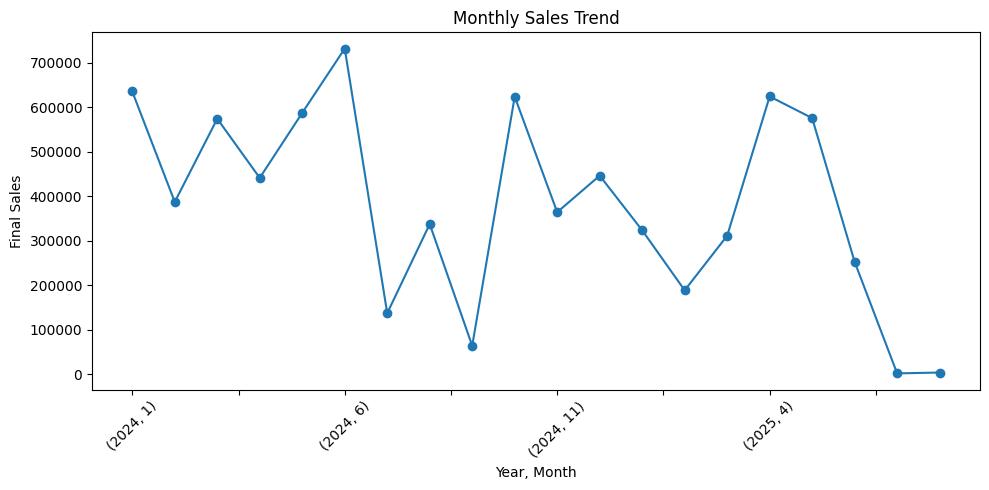

In [46]:
monthly_trend_plot = df_clean.groupby(['Order Year', 'Order Month'])['Final Sales'].sum()

plt.figure(figsize=(10, 5))
monthly_trend_plot.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Year, Month')
plt.ylabel('Final Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 9: Identify Data Issues
Even after cleaning, I want to double check the data for any remaining issues.

### Remaining Missing Values

In [47]:
df_clean.isnull().sum()

Order ID            0
Order Date          0
Customer Name       0
Region              0
Product             0
Category            0
Quantity            0
Unit Price          0
Discount            0
Payment Method      0
Order Status        0
Sales Rep           0
Customer Segment    0
Shipping Date       5
Total Sales         0
Discount Amount     0
Final Sales         0
Order Month         0
Order Year          0
Month Name          0
dtype: int64

### Negative Values
Checking if any Quantity, Unit Price or Final Sales values are negative.

In [48]:
negative_values = df_clean[(df_clean['Quantity'] < 0) | (df_clean['Unit Price'] < 0) | (df_clean['Final Sales'] < 0)]
negative_values

,Order ID,Order Date,Customer Name,Region,Product,Category,Quantity,Unit Price,Discount,Payment Method,Order Status,Sales Rep,Customer Segment,Shipping Date,Total Sales,Discount Amount,Final Sales,Order Month,Order Year,Month Name


### Unusual High-Value Orders
I will check for orders where Final Sales is much higher than normal.

In [49]:
high_value_limit = df_clean['Final Sales'].mean() + 3 * df_clean['Final Sales'].std()
unusual_orders = df_clean[df_clean['Final Sales'] > high_value_limit]
unusual_orders

,Order ID,Order Date,Customer Name,Region,Product,Category,Quantity,Unit Price,Discount,Payment Method,Order Status,Sales Rep,Customer Segment,Shipping Date,Total Sales,Discount Amount,Final Sales,Order Month,Order Year,Month Name
26,ORD-1026,2024-12-04,Ayesha Qureshi,East,Standing Desk,Furniture,3.0,72250.0,0.05,Card,Completed,Nadia,Student,2024-04-17,216750.0,10837.5,205912.5,12,2024,December
77,ORD-1077,2024-06-17,Bilal Akhtar,West,Standing Desk,Furniture,3.0,71000.0,0.00,Bank Transfer,Completed,Hina,Corporate,2024-06-25,213000.0,0.0,213000.0,6,2024,June
199,ORD-1197,2025-04-19,Farhan Malik,South,Standing Desk,Furniture,3.0,72450.0,0.00,Card,Pending,Nadia,Student,2025-04-27,217350.0,0.0,217350.0,4,2025,April
269,ORD-1265,2025-05-19,Ahmed Sheikh,South,Standing Desk,Furniture,3.0,73200.0,0.05,Card,Completed,Mehwish,Small Business,2025-05-22,219600.0,10980.0,208620.0,5,2025,May
277,ORD-1273,2024-03-06,Fatima Siddiqui,East,smart watch,Electronics,8.0,24700.0,0.10,Easypaisa,Completed,Mehwish,Small Business,2024-03-13,197600.0,19760.0,177840.0,3,2024,March
283,ORD-1279,2024-02-07,Usman Mirza,North,Standing Desk,Furniture,3.0,70350.0,0.10,Card,Completed,Nadia,Corporate,2024-02-14,211050.0,21105.0,189945.0,2,2024,February


### Inconsistent Text Values
Checking the unique values in the Region and Payment Method columns to make sure everything is consistent now.

In [50]:
print(df_clean['Region'].unique())
print(df_clean['Payment Method'].unique())

<StringArray>
['North', 'South', 'West', 'Central', 'East', 'Unknown']
Length: 6, dtype: str
<StringArray>
['Card', 'Cash', 'Bank Transfer', 'Jazzcash', 'Easypaisa', 'Unknown']
Length: 6, dtype: str


## Step 10: Export Results
Now I will export the cleaned dataset and the summary tables.

### Export Cleaned Dataset as CSV

In [51]:
df_clean.to_csv('cleaned_sales_data.csv', index=False)

### Export Summary Tables as CSV

In [52]:
sales_by_region.to_csv('sales_by_region.csv')
sales_by_category.to_csv('sales_by_category.csv')
sales_by_product.to_csv('sales_by_product.csv')
sales_by_segment.to_csv('sales_by_segment.csv')
sales_by_payment.to_csv('sales_by_payment.csv')
sales_by_month.to_csv('sales_by_month.csv')

### Export Everything into One Excel File with Multiple Sheets

In [53]:
with pd.ExcelWriter('sales_analysis_report.xlsx') as writer:
    df_clean.to_excel(writer, sheet_name='Cleaned Data', index=False)
    sales_by_region.to_excel(writer, sheet_name='By Region')
    sales_by_category.to_excel(writer, sheet_name='By Category')
    sales_by_product.to_excel(writer, sheet_name='By Product')
    sales_by_segment.to_excel(writer, sheet_name='By Segment')
    sales_by_payment.to_excel(writer, sheet_name='By Payment Method')
    sales_by_month.to_excel(writer, sheet_name='By Month')

## Step 11: Final Report

**1. What data quality issues did you find?**

The dataset had a lot of problems. There were duplicate rows, extra spaces in text, and text written in
different cases like "north", "NORTH" and "North". The Order Date column had many different date formats.
Quantity had one value written as the word "two" instead of a number. Unit Price had commas and the text
"PKR" in some values. Discount was written both as a decimal like 0.1 and as a percentage like "10%".
Some columns also had missing values.

**2. How did you clean the data?**

I removed the duplicate rows first, then removed extra spaces and made the text columns consistent using
title case. I filled missing text values with "Unknown". I converted the Order Date and Shipping Date
columns to a proper datetime format. I converted Quantity, Unit Price and Discount into numeric columns by
fixing the text issues in them. Finally, I removed rows that still had missing or invalid values in the
important columns.

**3. Which region generated the highest sales?**

The **West** region generated the highest sales.

**4. Which product category performed best?**

The **Furniture** category performed the best in terms of revenue.

**5. What were the top 5 products by revenue?**

The top 5 products by revenue were Standing Desk, Noise Cancelling Headphones, Office Chair, Bluetooth
Speaker and Smart Watch.

**6. Which month had the highest sales?**

**May** had the highest sales overall.

**7. What is the average order value?**

The average order value is around **PKR 38,080**.

**8. What business recommendations would you give?**

Since Furniture and Electronics bring in the most revenue, the business should focus more on promoting
these categories. The West and South regions are performing well, so the same strategies used there could
be applied to weaker regions like Central. Since Card and JazzCash are popular payment methods, the
business should make sure these options are always working smoothly. The company should also try to reduce
the number of Cancelled and Refunded orders, since these are lowering the total possible revenue.